In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier

In [3]:
#1 Load Dataset
df = pd.read_csv("knn_telecom.csv")
#Remove Id columns if present
df = df.loc[:, ~df.columns.str.lower().str.contains("id")]

In [8]:
#2 Handle Missing Values Properly
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

In [9]:
#3 Separate Features and Target
X = df.drop("Churn", axis=1)
y = df["Churn"]

#Identify feature types
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

In [10]:
#4 Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first"), categorical_features)
    ]
)

In [12]:
#5 Cross-Validation to Select Best K
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_values = range(1, 16)
cv_scores = []

for k in k_values:
    model = Pipeline([
        ("preprocessing", preprocessor),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    cv_scores.append(scores.mean())

#Display results
for k, score in zip(k_values, cv_scores):
    print(f"K = {k} | CV Accuracy = {round(score,4)}")

best_k = k_values[np.argmax(cv_scores)]
print("\nBest K Selected:", best_k)

K = 1 | CV Accuracy = 0.9533
K = 2 | CV Accuracy = 0.94
K = 3 | CV Accuracy = 0.9667
K = 4 | CV Accuracy = 0.96
K = 5 | CV Accuracy = 0.96
K = 6 | CV Accuracy = 0.96
K = 7 | CV Accuracy = 0.96
K = 8 | CV Accuracy = 0.9667
K = 9 | CV Accuracy = 0.96
K = 10 | CV Accuracy = 0.96
K = 11 | CV Accuracy = 0.96
K = 12 | CV Accuracy = 0.96
K = 13 | CV Accuracy = 0.9667
K = 14 | CV Accuracy = 0.9667
K = 15 | CV Accuracy = 0.96

Best K Selected: 3


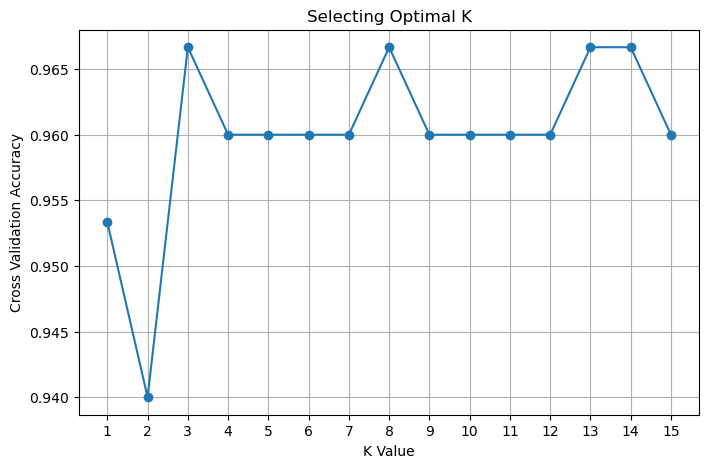

In [14]:
#6 Plot Accuracy vs K
plt.figure(figsize=(8,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Cross Validation Accuracy")
plt.title("Selecting Optimal K")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [15]:
#7 Train Final Model with Best K
final_model = Pipeline([
    ("preprocessing", preprocessor),
    ("knn", KNeighborsClassifier(n_neighbors=best_k))
])

final_model.fit(X, y)

,steps,"[('preprocessing', ...), ('knn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [18]:
#8 User Input Prediction
#Modify values as required
user_data = {
    "Age": 40,
    "Gender": "Male",
    "PlanType": "Premium",
    "Tenure": 12,
    "MonthlyUsage": 350
}

user_df = pd.DataFrame([user_data])

prediction = final_model.predict(user_df)[0]
probability = final_model.predict_proba(user_df)[0]

print("\nUser Input:")
print(user_df)

print("\nPredicted Churn:", prediction)
print("Prediction Probability:", probability)


User Input:
   Age Gender PlanType  Tenure  MonthlyUsage
0   40   Male  Premium      12           350

Predicted Churn: 1
Prediction Probability: [0. 1.]
